# Pharmacy Sales - Feature Engineering for Time Series Forecasting

This notebook prepares features for three modeling approaches:
1. **SARIMA** (Seasonal ARIMA) - Statistical time series model
2. **Baseline Models** - Simple forecasting benchmarks
3. **XGBoost** - Machine learning model with engineered features

**Data Source:** Uses cleaned data from `data_cleaning.ipynb` which has:
- Outliers handled (capped using IQR method)
- Data quality score: 100%
- Standardized features available
- Incomplete periods flagged
- Complete years only (2014-2018)

## Setup & Imports

In [26]:
# Add project root to path
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✓ Project root added: {project_root}")

✓ Project root added: /home/brenda/final year project/PharmacyForecastingSystem


In [27]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime, timedelta

# Time series specific
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✓ Packages imported successfully")

✓ Packages imported successfully


## 1. LOAD AND PREPARE BASE DATA

**Using cleaned data** from the data cleaning pipeline:
- Outliers capped using IQR method
- 100% data quality score
- Ready for feature engineering

In [28]:
# Load cleaned data (recommended: use modeling dataset with complete years only)
data_path = Path(project_root) / 'data' / 'processed' / 'sales_modeling.csv'

print("Loading cleaned data...")
print(f"Source: {data_path}")

df = pd.read_csv(data_path)

# Convert dates
df['week_start_date'] = pd.to_datetime(df['week_start_date'])
df['week_end_date'] = pd.to_datetime(df['week_end_date'])

print(f"\n✓ Cleaned data loaded: {len(df):,} rows")
print(f"Date range: {df['week_start_date'].min().date()} to {df['week_start_date'].max().date()}")
print(f"Unique drugs: {df['drug_name'].nunique()}")
print(f"Complete years only: {df['is_complete_year'].all()}")

# Display data info
print("\nAvailable columns:")
for col in df.columns:
    print(f"  - {col}")

Loading cleaned data...
Source: /home/brenda/final year project/PharmacyForecastingSystem/data/processed/sales_modeling.csv

✓ Cleaned data loaded: 2,053 rows
Date range: 2013-12-30 to 2018-12-24
Unique drugs: 8
Complete years only: True

Available columns:
  - year
  - week_number
  - week_start_date
  - week_end_date
  - total_quantity
  - avg_daily_quantity
  - drug_name
  - atc_code
  - drug_id
  - is_complete_year
  - total_quantity_scaled


In [29]:
# Verify data quality (should already be clean)
print("=" * 60)
print("DATA QUALITY VERIFICATION")
print("=" * 60)
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Negative quantities: {(df['total_quantity'] < 0).sum()}")
print(f"Zero quantities: {(df['total_quantity'] == 0).sum()}")

print("\n" + "=" * 60)
print("CLEANED DATA SUMMARY")
print("=" * 60)
print(f"Original skewness reduced: High → {df['total_quantity'].skew():.2f}")
print(f"Outliers handled: Capped using IQR method")
print(f"Data completeness: {df['is_complete_year'].sum()} / {len(df)} records from complete years")
print(f"\n✓ Data is clean and ready for feature engineering")

DATA QUALITY VERIFICATION
Missing values: 0
Duplicates: 0
Negative quantities: 0
Zero quantities: 0

CLEANED DATA SUMMARY
Original skewness reduced: High → 0.98
Outliers handled: Capped using IQR method
Data completeness: 2053 / 2053 records from complete years

✓ Data is clean and ready for feature engineering


## 2. SELECT TOP DRUGS FOR MODELING

We'll focus on top-selling drugs with sufficient historical data for reliable forecasting.

In [30]:
# Analyze drug data availability
drug_stats = df.groupby('drug_name').agg({
    'total_quantity': ['sum', 'mean', 'count'],
    'week_start_date': ['min', 'max']
})

drug_stats.columns = ['total_sales', 'avg_sales', 'num_weeks', 'first_date', 'last_date']
drug_stats['weeks_span'] = (drug_stats['last_date'] - drug_stats['first_date']).dt.days / 7
drug_stats['data_completeness'] = (drug_stats['num_weeks'] / drug_stats['weeks_span']) * 100

# Select top 10 drugs with good data quality
# Criteria: Top sales + at least 52 weeks of data + >80% completeness
top_drugs = drug_stats[
    (drug_stats['num_weeks'] >= 52) & 
    (drug_stats['data_completeness'] >= 80)
].nlargest(10, 'total_sales')

print("=" * 60)
print("TOP 10 DRUGS SELECTED FOR MODELING")
print("=" * 60)
display(top_drugs)

selected_drugs = top_drugs.index.tolist()
print(f"\n✓ Selected {len(selected_drugs)} drugs for forecasting")

TOP 10 DRUGS SELECTED FOR MODELING


,total_sales,avg_sales,num_weeks,first_date,last_date,weeks_span,data_completeness
drug_name,,,,,,,
N02BE,25973.375,99.514847,261,2013-12-30,2018-12-24,260.0,100.384615
N05B,15856.750,60.753831,261,2013-12-30,2018-12-24,260.0,100.384615
R03,9635.250,36.916667,261,2013-12-30,2018-12-24,260.0,100.384615
M01AB,8952.000,34.298851,261,2013-12-30,2018-12-24,260.0,100.384615
N02BA,7173.000,27.482759,261,2013-12-30,2018-12-24,260.0,100.384615
M01AE,6989.000,26.777778,261,2013-12-30,2018-12-24,260.0,100.384615
R06,4969.000,19.038314,261,2013-12-30,2018-12-24,260.0,100.384615
N05C,1050.000,4.646018,226,2014-01-06,2018-12-24,259.0,87.258687



✓ Selected 8 drugs for forecasting


In [31]:
# Filter data to selected drugs
df_model = df[df['drug_name'].isin(selected_drugs)].copy()
print(f"Modeling dataset: {len(df_model):,} rows")

Modeling dataset: 2,053 rows


## 3. TIME-BASED FEATURES

Create temporal features for pattern recognition.

In [32]:
# Extract time components
df_model['year'] = df_model['week_start_date'].dt.year
df_model['month'] = df_model['week_start_date'].dt.month
df_model['quarter'] = df_model['week_start_date'].dt.quarter
df_model['day_of_year'] = df_model['week_start_date'].dt.dayofyear
df_model['week_of_year'] = df_model['week_start_date'].dt.isocalendar().week

# Cyclical encoding for seasonal patterns
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['week_sin'] = np.sin(2 * np.pi * df_model['week_of_year'] / 52)
df_model['week_cos'] = np.cos(2 * np.pi * df_model['week_of_year'] / 52)

print("✓ Time-based features created:")
print("  - Year, month, quarter")
print("  - Day of year, week of year")
print("  - Cyclical encodings (sin/cos)")

✓ Time-based features created:
  - Year, month, quarter
  - Day of year, week of year
  - Cyclical encodings (sin/cos)


## 4. LAG FEATURES

Create lag features to capture temporal dependencies.

In [33]:
def create_lag_features(df, group_col, value_col, lags):
    """
    Create lag features for time series forecasting.
    
    Parameters:
    - df: DataFrame
    - group_col: Column to group by (e.g., 'drug_name')
    - value_col: Column to create lags for (e.g., 'total_quantity')
    - lags: List of lag periods
    """
    df = df.sort_values(['drug_name', 'week_start_date']).copy()
    
    for lag in lags:
        df[f'{value_col}_lag_{lag}'] = df.groupby(group_col)[value_col].shift(lag)
    
    return df

# Create lag features: 1 week, 2 weeks, 4 weeks (1 month), 13 weeks (~1 quarter), 52 weeks (1 year)
lags = [1, 2, 4, 13, 52]
df_model = create_lag_features(df_model, 'drug_name', 'total_quantity', lags)

print(f"✓ Lag features created: {lags}")

✓ Lag features created: [1, 2, 4, 13, 52]


## 5. ROLLING WINDOW FEATURES

Create rolling statistics to capture trends.

In [34]:
def create_rolling_features(df, group_col, value_col, windows):
    """
    Create rolling mean, std, min, max features.
    
    Parameters:
    - df: DataFrame
    - group_col: Column to group by
    - value_col: Column to compute rolling stats on
    - windows: List of window sizes
    """
    df = df.sort_values([group_col, 'week_start_date']).copy()
    
    for window in windows:
        # Rolling mean
        df[f'{value_col}_rolling_mean_{window}'] = (
            df.groupby(group_col)[value_col]
            .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).mean())
        )
        
        # Rolling std
        df[f'{value_col}_rolling_std_{window}'] = (
            df.groupby(group_col)[value_col]
            .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).std())
        )
        
        # Rolling min
        df[f'{value_col}_rolling_min_{window}'] = (
            df.groupby(group_col)[value_col]
            .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).min())
        )
        
        # Rolling max
        df[f'{value_col}_rolling_max_{window}'] = (
            df.groupby(group_col)[value_col]
            .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).max())
        )
    
    return df

# Create rolling features: 4 weeks, 13 weeks, 26 weeks, 52 weeks
windows = [4, 13, 26, 52]
df_model = create_rolling_features(df_model, 'drug_name', 'total_quantity', windows)

print(f"✓ Rolling window features created for windows: {windows}")
print("  - Rolling mean, std, min, max")

✓ Rolling window features created for windows: [4, 13, 26, 52]
  - Rolling mean, std, min, max


## 6. EXPONENTIAL WEIGHTED FEATURES

Create exponentially weighted moving averages (EWMA) - gives more weight to recent observations.

In [35]:
def create_ewm_features(df, group_col, value_col, spans):
    """
    Create exponentially weighted moving average features.
    """
    df = df.sort_values([group_col, 'week_start_date']).copy()
    
    for span in spans:
        df[f'{value_col}_ewm_{span}'] = (
            df.groupby(group_col)[value_col]
            .transform(lambda x: x.shift(1).ewm(span=span, adjust=False).mean())
        )
    
    return df

# Create EWMA features with different spans
spans = [4, 13, 26]
df_model = create_ewm_features(df_model, 'drug_name', 'total_quantity', spans)

print(f"✓ Exponential weighted features created for spans: {spans}")

✓ Exponential weighted features created for spans: [4, 13, 26]


## 7. TREND FEATURES

In [36]:
# Time index (weeks since start for each drug)
df_model = df_model.sort_values(['drug_name', 'week_start_date']).copy()
df_model['time_index'] = df_model.groupby('drug_name').cumcount() + 1

# Percentage change features
df_model['pct_change_1w'] = df_model.groupby('drug_name')['total_quantity'].pct_change(1)
df_model['pct_change_4w'] = df_model.groupby('drug_name')['total_quantity'].pct_change(4)

# Difference features
df_model['diff_1w'] = df_model.groupby('drug_name')['total_quantity'].diff(1)
df_model['diff_4w'] = df_model.groupby('drug_name')['total_quantity'].diff(4)

print("✓ Trend features created:")
print("  - Time index")
print("  - Percentage change (1w, 4w)")
print("  - Differences (1w, 4w)")

✓ Trend features created:
  - Time index
  - Percentage change (1w, 4w)
  - Differences (1w, 4w)


## 8. STATISTICAL FEATURES

In [37]:
# Expanding window statistics (all historical data up to current point)
df_model['expanding_mean'] = (
    df_model.groupby('drug_name')['total_quantity']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
)

df_model['expanding_std'] = (
    df_model.groupby('drug_name')['total_quantity']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).std())
)

# Ratio to mean (normalized demand)
df_model['ratio_to_expanding_mean'] = (
    df_model['total_quantity'] / df_model['expanding_mean']
)

print("✓ Statistical features created:")
print("  - Expanding mean and std")
print("  - Ratio to expanding mean")

✓ Statistical features created:
  - Expanding mean and std
  - Ratio to expanding mean


## 9. DRUG-SPECIFIC FEATURES

In [38]:
# Calculate drug-level statistics
drug_level_stats = df_model.groupby('drug_name')['total_quantity'].agg([
    'mean', 'std', 'min', 'max'
]).reset_index()

drug_level_stats.columns = ['drug_name', 'drug_avg_sales', 'drug_std_sales', 
                              'drug_min_sales', 'drug_max_sales']

# Coefficient of variation
drug_level_stats['drug_cv'] = (
    drug_level_stats['drug_std_sales'] / drug_level_stats['drug_avg_sales']
)

# Merge back
df_model = df_model.merge(drug_level_stats, on='drug_name', how='left')

# Encode ATC code (first character indicates therapeutic category)
df_model['atc_main_group'] = df_model['atc_code'].str[0]

print("✓ Drug-specific features created:")
print("  - Average, std, min, max sales per drug")
print("  - Coefficient of variation")
print("  - ATC main therapeutic group")

✓ Drug-specific features created:
  - Average, std, min, max sales per drug
  - Coefficient of variation
  - ATC main therapeutic group


## 10. FEATURE SUMMARY

In [39]:
print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

# Categorize features
time_features = ['year', 'month', 'quarter', 'day_of_year', 'week_of_year', 
                 'month_sin', 'month_cos', 'week_sin', 'week_cos']

lag_features = [col for col in df_model.columns if 'lag_' in col]
rolling_features = [col for col in df_model.columns if 'rolling_' in col]
ewm_features = [col for col in df_model.columns if 'ewm_' in col]
trend_features = ['time_index', 'pct_change_1w', 'pct_change_4w', 'diff_1w', 'diff_4w']
stat_features = ['expanding_mean', 'expanding_std', 'ratio_to_expanding_mean']
drug_features = ['drug_avg_sales', 'drug_std_sales', 'drug_min_sales', 
                 'drug_max_sales', 'drug_cv', 'atc_main_group']

print(f"\nTotal features created: {len(df_model.columns)}")
print(f"\nFeature categories:")
print(f"  • Time-based features: {len(time_features)}")
print(f"  • Lag features: {len(lag_features)}")
print(f"  • Rolling window features: {len(rolling_features)}")
print(f"  • Exponential weighted features: {len(ewm_features)}")
print(f"  • Trend features: {len(trend_features)}")
print(f"  • Statistical features: {len(stat_features)}")
print(f"  • Drug-specific features: {len(drug_features)}")

print(f"\nDataset shape: {df_model.shape}")
print(f"Date range: {df_model['week_start_date'].min()} to {df_model['week_start_date'].max()}")

FEATURE ENGINEERING SUMMARY

Total features created: 57

Feature categories:
  • Time-based features: 9
  • Lag features: 5
  • Rolling window features: 16
  • Exponential weighted features: 3
  • Trend features: 5
  • Statistical features: 3
  • Drug-specific features: 6

Dataset shape: (2053, 57)
Date range: 2013-12-30 00:00:00 to 2018-12-24 00:00:00


In [40]:
# Check for missing values after feature engineering
missing_summary = df_model.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

print("\n" + "=" * 60)
print("MISSING VALUES AFTER FEATURE ENGINEERING")
print("=" * 60)

if len(missing_summary) > 0:
    print("\nColumns with missing values:")
    for col, count in missing_summary.items():
        pct = (count / len(df_model)) * 100
        print(f"  {col}: {count:,} ({pct:.2f}%)")
else:
    print("✓ No missing values!")


MISSING VALUES AFTER FEATURE ENGINEERING

Columns with missing values:
  total_quantity_lag_52: 416 (20.26%)
  total_quantity_lag_13: 104 (5.07%)
  total_quantity_lag_4: 32 (1.56%)
  diff_4w: 32 (1.56%)
  pct_change_4w: 32 (1.56%)
  total_quantity_rolling_std_52: 16 (0.78%)
  total_quantity_rolling_std_26: 16 (0.78%)
  expanding_std: 16 (0.78%)
  total_quantity_rolling_std_4: 16 (0.78%)
  total_quantity_rolling_std_13: 16 (0.78%)
  total_quantity_lag_2: 16 (0.78%)
  total_quantity_ewm_4: 8 (0.39%)
  total_quantity_ewm_13: 8 (0.39%)
  total_quantity_lag_1: 8 (0.39%)
  total_quantity_ewm_26: 8 (0.39%)
  pct_change_1w: 8 (0.39%)
  total_quantity_rolling_max_52: 8 (0.39%)
  expanding_mean: 8 (0.39%)
  diff_1w: 8 (0.39%)
  total_quantity_rolling_min_26: 8 (0.39%)
  total_quantity_rolling_min_52: 8 (0.39%)
  total_quantity_rolling_mean_52: 8 (0.39%)
  total_quantity_rolling_max_26: 8 (0.39%)
  total_quantity_rolling_mean_26: 8 (0.39%)
  total_quantity_rolling_max_13: 8 (0.39%)
  total_quant

## 11. PREPARE DATA FOR DIFFERENT MODELS

### 11.1 Baseline Models Data

Simple forecasting methods that serve as benchmarks.

In [41]:
# For baseline models, we need clean time series data
# Remove rows with missing values in target variable
df_baseline = df_model[['drug_name', 'week_start_date', 'total_quantity']].copy()
df_baseline = df_baseline.dropna()

print("=" * 60)
print("BASELINE MODELS DATA")
print("=" * 60)
print(f"Shape: {df_baseline.shape}")
print(f"Drugs: {df_baseline['drug_name'].nunique()}")
print(f"\nBaseline models to implement:")
print("  1. Naive forecast (last value)")
print("  2. Moving average (4 weeks)")
print("  3. Seasonal naive (same week last year)")
print("  4. Exponential smoothing")

print(f"\n✓ Baseline data ready: {len(df_baseline):,} rows")

BASELINE MODELS DATA
Shape: (2053, 3)
Drugs: 8

Baseline models to implement:
  1. Naive forecast (last value)
  2. Moving average (4 weeks)
  3. Seasonal naive (same week last year)
  4. Exponential smoothing

✓ Baseline data ready: 2,053 rows


### 11.2 SARIMA Data

SARIMA requires univariate time series for each drug.

In [42]:
# SARIMA data preparation
# Each drug needs its own time series
df_sarima = df_model[['drug_name', 'week_start_date', 'total_quantity']].copy()
df_sarima = df_sarima.dropna()

print("=" * 60)
print("SARIMA DATA")
print("=" * 60)
print(f"Shape: {df_sarima.shape}")

# Check data frequency for each drug
print("\nData availability per drug:")
for drug in selected_drugs[:5]:  # Show first 5
    drug_data = df_sarima[df_sarima['drug_name'] == drug]
    print(f"  {drug}: {len(drug_data)} weeks")

print("\n✓ SARIMA data ready")
print("\nNext steps for SARIMA:")
print("  1. Check stationarity (ADF test)")
print("  2. Analyze ACF/PACF plots")
print("  3. Determine (p,d,q) and (P,D,Q,s) parameters")
print("  4. Fit SARIMA models per drug")

SARIMA DATA
Shape: (2053, 3)

Data availability per drug:
  N02BE: 261 weeks
  N05B: 261 weeks
  R03: 261 weeks
  M01AB: 261 weeks
  N02BA: 261 weeks

✓ SARIMA data ready

Next steps for SARIMA:
  1. Check stationarity (ADF test)
  2. Analyze ACF/PACF plots
  3. Determine (p,d,q) and (P,D,Q,s) parameters
  4. Fit SARIMA models per drug


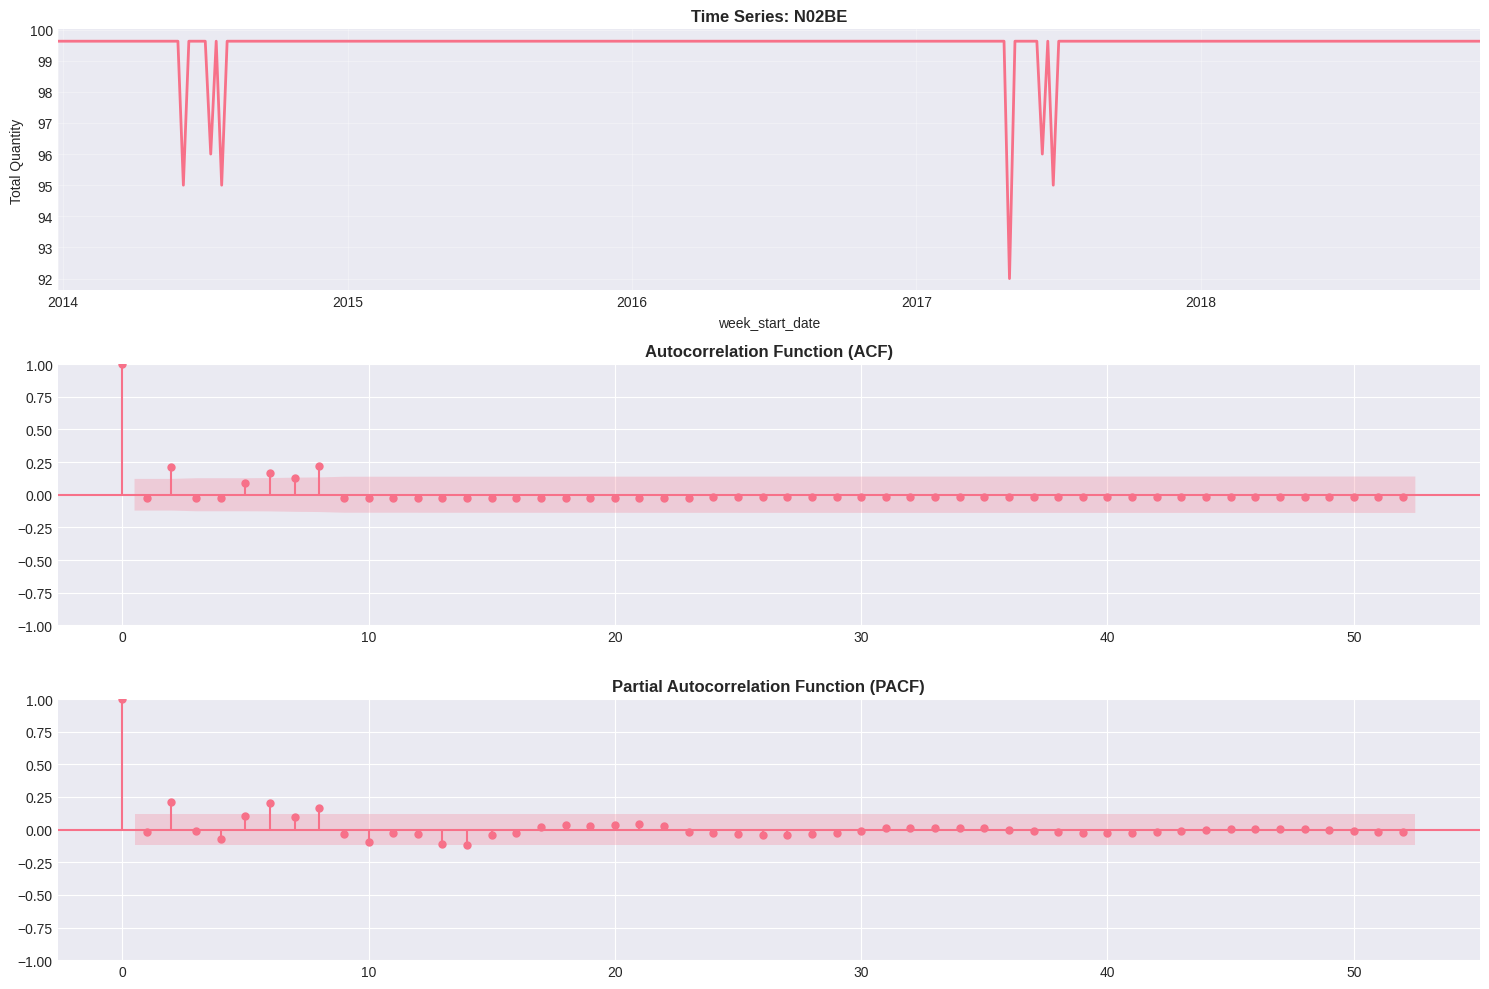

ACF/PACF plots can help determine SARIMA parameters (p, d, q)


In [43]:
# Visualize time series for first drug (for SARIMA inspection)
first_drug = selected_drugs[0]
drug_ts = df_sarima[df_sarima['drug_name'] == first_drug].set_index('week_start_date')['total_quantity']

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Time series plot
drug_ts.plot(ax=axes[0], linewidth=2)
axes[0].set_title(f'Time Series: {first_drug}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Quantity')
axes[0].grid(True, alpha=0.3)

# ACF plot
plot_acf(drug_ts.dropna(), lags=52, ax=axes[1])
axes[1].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')

# PACF plot
plot_pacf(drug_ts.dropna(), lags=52, ax=axes[2])
axes[2].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"ACF/PACF plots can help determine SARIMA parameters (p, d, q)")

### 11.3 XGBoost Data

Machine learning model with all engineered features.

In [44]:
# XGBoost data preparation
# Remove rows with missing values in lag features (first few weeks)
df_xgboost = df_model.copy()

# Drop rows where we don't have enough lag data
# Keep rows where at least lag_1 is available
df_xgboost = df_xgboost.dropna(subset=['total_quantity_lag_1'])

print("=" * 60)
print("XGBOOST DATA")
print("=" * 60)
print(f"Shape: {df_xgboost.shape}")
print(f"Features: {len(df_xgboost.columns)}")

# Identify feature columns
target = 'total_quantity'
exclude_cols = ['week_start_date', 'week_end_date', 'drug_name', 'drug_id', 
                'atc_code', target, 'avg_daily_quantity']

feature_cols = [col for col in df_xgboost.columns if col not in exclude_cols]

print(f"\nTarget variable: {target}")
print(f"Number of features: {len(feature_cols)}")
print(f"\nFeature columns (first 20):")
for i, col in enumerate(feature_cols[:20], 1):
    print(f"  {i}. {col}")

if len(feature_cols) > 20:
    print(f"  ... and {len(feature_cols) - 20} more")

XGBOOST DATA
Shape: (2045, 57)
Features: 57

Target variable: total_quantity
Number of features: 50

Feature columns (first 20):
  1. year
  2. week_number
  3. is_complete_year
  4. total_quantity_scaled
  5. month
  6. quarter
  7. day_of_year
  8. week_of_year
  9. month_sin
  10. month_cos
  11. week_sin
  12. week_cos
  13. total_quantity_lag_1
  14. total_quantity_lag_2
  15. total_quantity_lag_4
  16. total_quantity_lag_13
  17. total_quantity_lag_52
  18. total_quantity_rolling_mean_4
  19. total_quantity_rolling_std_4
  20. total_quantity_rolling_min_4
  ... and 30 more


In [45]:
# Handle remaining missing values for XGBoost
missing_in_features = df_xgboost[feature_cols].isnull().sum()
missing_in_features = missing_in_features[missing_in_features > 0]

if len(missing_in_features) > 0:
    print("\nHandling missing values in features:")
    for col in missing_in_features.index:
        # Fill missing with forward fill, then backward fill
        df_xgboost[col] = df_xgboost.groupby('drug_name')[col].fillna(method='ffill').fillna(method='bfill')
        # If still missing, fill with 0
        df_xgboost[col] = df_xgboost[col].fillna(0)
    print("  ✓ Missing values handled")

# Final check
remaining_missing = df_xgboost[feature_cols].isnull().sum().sum()
print(f"\nRemaining missing values in features: {remaining_missing}")

print(f"\n✓ XGBoost data ready: {len(df_xgboost):,} rows")


Handling missing values in features:
  ✓ Missing values handled

Remaining missing values in features: 0

✓ XGBoost data ready: 2,045 rows


In [46]:
# Encode categorical features for XGBoost
from sklearn.preprocessing import LabelEncoder

# Encode drug_name
le_drug = LabelEncoder()
df_xgboost['drug_name_encoded'] = le_drug.fit_transform(df_xgboost['drug_name'])

# Encode atc_main_group
le_atc = LabelEncoder()
df_xgboost['atc_main_group_encoded'] = le_atc.fit_transform(df_xgboost['atc_main_group'])

# Update feature list
feature_cols.append('drug_name_encoded')
feature_cols.append('atc_main_group_encoded')
feature_cols.remove('atc_main_group')  # Remove original categorical

print("✓ Categorical features encoded")
print(f"Final number of features: {len(feature_cols)}")

✓ Categorical features encoded
Final number of features: 51


## 12. TRAIN-TEST SPLIT

Time series requires chronological split (no random shuffle).

In [47]:
# Temporal train/validation split by year (academically rigorous methodology)
# ┌──────────────────────────────────────────────────────────────────┐
# │  Train      │  2014–2017  │  Learn historical patterns           │
# │  Validation │  2018       │  Evaluate model (tune/compare)       │
# │  Final Test │  2019       │  model_validation_2019.ipynb         │
# └──────────────────────────────────────────────────────────────────┘
TRAIN_END_YEAR = 2017
VAL_YEAR       = 2018
split_date     = pd.Timestamp(f'{VAL_YEAR}-01-01')

print("=" * 60)
print("TEMPORAL TRAIN-VALIDATION SPLIT (YEAR-BASED)")
print("=" * 60)
print(f"Training period  : 2014 – {TRAIN_END_YEAR}")
print(f"Validation period: {VAL_YEAR} (full year — ~52 weeks)")
print(f"Final test       : 2019  → evaluated in model_validation_2019.ipynb")
print(f"Split date       : {split_date.date()}")

# Split for XGBoost
train_xgb = df_xgboost[df_xgboost['week_start_date'] <  split_date].copy()
test_xgb  = df_xgboost[df_xgboost['week_start_date'] >= split_date].copy()

print(f"\nXGBoost:")
print(f"  Train      : {len(train_xgb):,} rows  ({train_xgb['week_start_date'].min().date()} → {train_xgb['week_start_date'].max().date()})")
print(f"  Validation : {len(test_xgb):,} rows  ({test_xgb['week_start_date'].min().date()} → {test_xgb['week_start_date'].max().date()})")

# Split for SARIMA
train_sarima = df_sarima[df_sarima['week_start_date'] <  split_date].copy()
test_sarima  = df_sarima[df_sarima['week_start_date'] >= split_date].copy()

print(f"\nSARIMA:")
print(f"  Train      : {len(train_sarima):,} rows")
print(f"  Validation : {len(test_sarima):,} rows")

# Split for Baseline
train_baseline = df_baseline[df_baseline['week_start_date'] <  split_date].copy()
test_baseline  = df_baseline[df_baseline['week_start_date'] >= split_date].copy()

print(f"\nBaseline:")
print(f"  Train      : {len(train_baseline):,} rows")
print(f"  Validation : {len(test_baseline):,} rows")


TEMPORAL TRAIN-VALIDATION SPLIT (YEAR-BASED)
Training period  : 2014 – 2017
Validation period: 2018 (full year — ~52 weeks)
Final test       : 2019  → evaluated in model_validation_2019.ipynb
Split date       : 2018-01-01

XGBoost:
  Train      : 1,638 rows  (2014-01-06 → 2017-12-25)
  Validation : 407 rows  (2018-01-01 → 2018-12-24)

SARIMA:
  Train      : 1,646 rows
  Validation : 407 rows

Baseline:
  Train      : 1,646 rows
  Validation : 407 rows


## 13. FEATURE IMPORTANCE PREVIEW

Quick correlation check to see which features might be important.

TOP 20 FEATURES BY CORRELATION WITH TARGET
total_quantity_scaled             1.000000
total_quantity_ewm_4              0.940159
total_quantity_rolling_mean_4     0.938732
total_quantity_ewm_13             0.937071
total_quantity_rolling_mean_13    0.932572
total_quantity_ewm_26             0.929813
total_quantity_rolling_mean_52    0.921821
total_quantity_rolling_mean_26    0.921678
total_quantity_rolling_min_4      0.920818
drug_avg_sales                    0.916822
expanding_mean                    0.916600
total_quantity_lag_1              0.915363
total_quantity_lag_2              0.910354
total_quantity_rolling_max_4      0.904520
total_quantity_rolling_min_13     0.904390
total_quantity_lag_4              0.900131
total_quantity_rolling_min_26     0.882501
total_quantity_rolling_min_52     0.864943
total_quantity_lag_13             0.863383
total_quantity_lag_52             0.858597
Name: total_quantity, dtype: float64


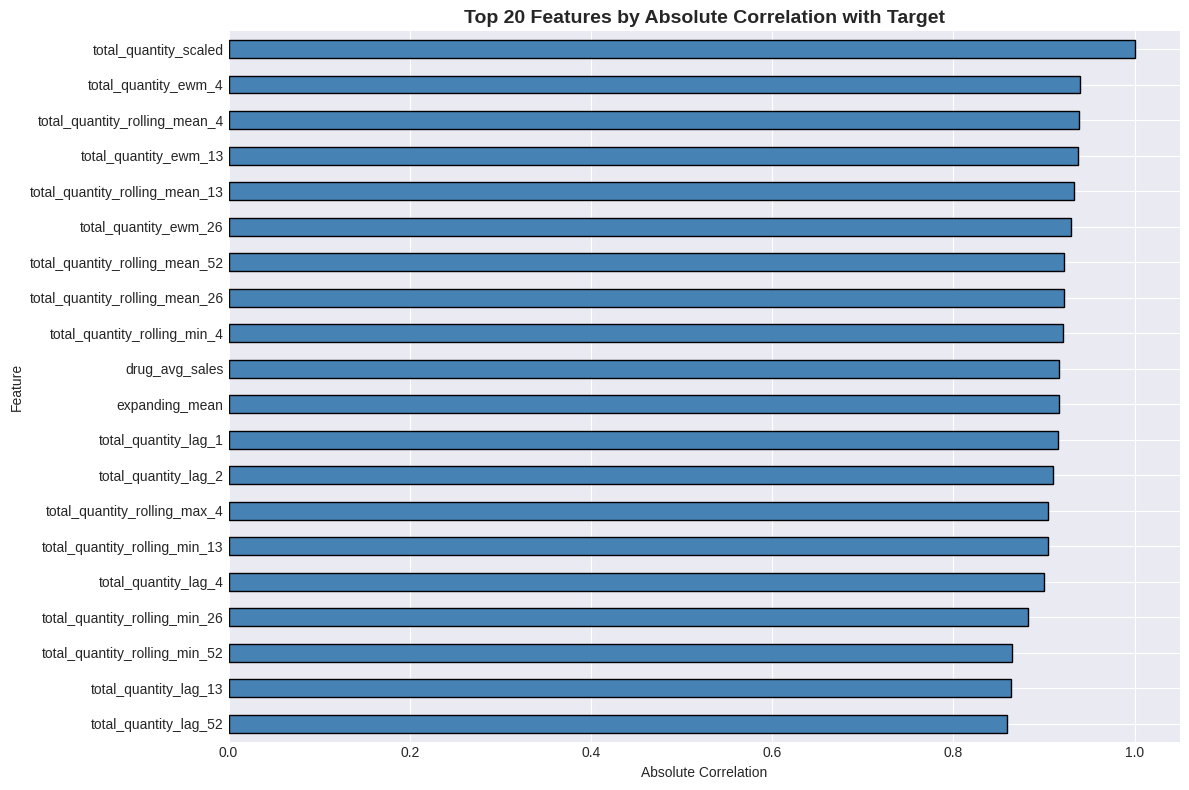

In [48]:
# Calculate correlation with target
correlations = train_xgb[feature_cols + [target]].corr()[target].drop(target)
correlations = correlations.abs().sort_values(ascending=False)

print("=" * 60)
print("TOP 20 FEATURES BY CORRELATION WITH TARGET")
print("=" * 60)
print(correlations.head(20))

# Visualize
plt.figure(figsize=(12, 8))
correlations.head(20).sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 20 Features by Absolute Correlation with Target', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 14. SAVE PREPARED DATASETS

In [49]:
# Create directory for processed data
import os
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

# Save datasets
print("=" * 60)
print("SAVING PREPARED DATASETS")
print("=" * 60)

# XGBoost data
train_xgb.to_csv(f'{output_dir}/train_xgboost.csv', index=False)
test_xgb.to_csv(f'{output_dir}/test_xgboost.csv', index=False)
print(f"✓ XGBoost data saved")

# SARIMA data
train_sarima.to_csv(f'{output_dir}/train_sarima.csv', index=False)
test_sarima.to_csv(f'{output_dir}/test_sarima.csv', index=False)
print(f"✓ SARIMA data saved")

# Baseline data
train_baseline.to_csv(f'{output_dir}/train_baseline.csv', index=False)
test_baseline.to_csv(f'{output_dir}/test_baseline.csv', index=False)
print(f"✓ Baseline data saved")

# Save feature list
with open(f'{output_dir}/feature_list.txt', 'w') as f:
    for feature in feature_cols:
        f.write(f"{feature}\n")
print(f"✓ Feature list saved")

# Save selected drugs list
with open(f'{output_dir}/selected_drugs.txt', 'w') as f:
    for drug in selected_drugs:
        f.write(f"{drug}\n")
print(f"✓ Selected drugs list saved")

# Save encoders
import pickle
with open(f'{output_dir}/label_encoders.pkl', 'wb') as f:
    pickle.dump({'drug': le_drug, 'atc': le_atc}, f)
print(f"✓ Label encoders saved")

print(f"\nAll files saved to: {output_dir}")

SAVING PREPARED DATASETS
✓ XGBoost data saved
✓ SARIMA data saved
✓ Baseline data saved
✓ Feature list saved
✓ Selected drugs list saved
✓ Label encoders saved

All files saved to: ../data/processed


## 15. DATA SUMMARY FOR MODELING

In [50]:
print("=" * 60)
print("FEATURE ENGINEERING COMPLETE - SUMMARY")
print("=" * 60)

print("\n📦 DATASETS PREPARED:")
print("\n1. BASELINE MODELS")
print(f"   - Train      : {len(train_baseline):,} rows")
print(f"   - Validation : {len(test_baseline):,} rows")
print(f"   - Features: drug_name, week_start_date, total_quantity")

print("\n2. SARIMA")
print(f"   - Train      : {len(train_sarima):,} rows")
print(f"   - Validation : {len(test_sarima):,} rows")
print(f"   - Format: Univariate time series per drug")
print(f"   - Drugs: {len(selected_drugs)}")

print("\n3. XGBOOST")
print(f"   - Train      : {len(train_xgb):,} rows")
print(f"   - Validation : {len(test_xgb):,} rows")
print(f"   - Features: {len(feature_cols)}")
print(f"   - Target: {target}")

print("\n📊 FEATURE CATEGORIES:")
print(f"   - Time-based: {len(time_features)}")
print(f"   - Lag features: {len(lag_features)}")
print(f"   - Rolling statistics: {len(rolling_features)}")
print(f"   - Exponential weighted: {len(ewm_features)}")
print(f"   - Trend features: {len(trend_features)}")
print(f"   - Statistical: {len(stat_features)}")
print(f"   - Drug-specific: {len(drug_features)}")

print("\n📅 TEMPORAL SPLIT:")
print(f"   - Training period  : 2014 – {TRAIN_END_YEAR}")
print(f"   - Validation period: {VAL_YEAR} (full year)")
print(f"   - Final test       : 2019 — evaluated in model_validation_2019.ipynb")

print("\n💾 OUTPUT FILES:")
print(f"   - {output_dir}/train_xgboost.csv")
print(f"   - {output_dir}/test_xgboost.csv")
print(f"   - {output_dir}/train_sarima.csv")
print(f"   - {output_dir}/test_sarima.csv")
print(f"   - {output_dir}/train_baseline.csv")
print(f"   - {output_dir}/test_baseline.csv")
print(f"   - {output_dir}/feature_list.txt")
print(f"   - {output_dir}/selected_drugs.txt")
print(f"   - {output_dir}/label_encoders.pkl")

print("\n✅ READY FOR MODELING!")
print("\nNext steps:")
print("   1. Build baseline models (naive, moving average, seasonal naive)")
print("   2. Fit SARIMA models (determine optimal parameters per drug)")
print("   3. Train XGBoost model on 2014-2017, validate on 2018")
print("   4. Compare all models using metrics (MAE, RMSE, MAPE)")
print("   5. Run model_validation_2019.ipynb for final 2019 test")


FEATURE ENGINEERING COMPLETE - SUMMARY

📦 DATASETS PREPARED:

1. BASELINE MODELS
   - Train      : 1,646 rows
   - Validation : 407 rows
   - Features: drug_name, week_start_date, total_quantity

2. SARIMA
   - Train      : 1,646 rows
   - Validation : 407 rows
   - Format: Univariate time series per drug
   - Drugs: 8

3. XGBOOST
   - Train      : 1,638 rows
   - Validation : 407 rows
   - Features: 51
   - Target: total_quantity

📊 FEATURE CATEGORIES:
   - Time-based: 9
   - Lag features: 5
   - Rolling statistics: 16
   - Exponential weighted: 3
   - Trend features: 5
   - Statistical: 3
   - Drug-specific: 6

📅 TEMPORAL SPLIT:
   - Training period  : 2014 – 2017
   - Validation period: 2018 (full year)
   - Final test       : 2019 — evaluated in model_validation_2019.ipynb

💾 OUTPUT FILES:
   - ../data/processed/train_xgboost.csv
   - ../data/processed/test_xgboost.csv
   - ../data/processed/train_sarima.csv
   - ../data/processed/test_sarima.csv
   - ../data/processed/train_baseli

## NOTES FOR MODEL BUILDING

### Baseline Models
- **Naive**: Use last observed value as forecast
- **Moving Average**: Average of last 4 weeks
- **Seasonal Naive**: Use value from same week last year (lag 52)
- **Exponential Smoothing**: Simple exponential smoothing with α optimization

### SARIMA
- Check stationarity with ADF test
- Use ACF/PACF plots to determine parameters
- Seasonality period: s=52 (weekly data, annual seasonality)
- Consider using `auto_arima` from `pmdarima` for parameter selection
- Fit separate model for each drug

### XGBoost
- Already has all engineered features
- Tune hyperparameters: `max_depth`, `learning_rate`, `n_estimators`, `subsample`
- Use time-based cross-validation (not random)
- Consider feature selection based on importance
- Can handle multiple drugs in single model

### Evaluation Metrics
- **MAE** (Mean Absolute Error): Average magnitude of errors
- **RMSE** (Root Mean Squared Error): Penalizes large errors
- **MAPE** (Mean Absolute Percentage Error): Scale-independent
- **R²**: Proportion of variance explained

### Model Comparison
Compare all models on test set using above metrics, then select best performer.